In [22]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)

iedb_I = pl.read_parquet("../../data/iedb_I/triad/staged/iedb_I_triad.conf_af3.parquet")

assay_type = pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_meta/assay_type.parquet"
)

iedb_II = iedb_II.filter(pl.col("cognate")).explode("references")

iedb_I = iedb_I.filter(pl.col("cognate")).explode("references")

In [44]:
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patheffects as pe


def plot_stacked_category_proportions(labels, values):
    """
    labels: list[str]                    # y-axis labels
    values: list[list[str]]              # per-label list of string categories

    Returns: (fig, ax)
    """
    # Order categories by overall frequency (most common first)
    total_counts = Counter(v for sub in values for v in sub)
    categories = [c for c, _ in total_counts.most_common()]

    n = len(labels)
    fig, ax = plt.subplots(figsize=(8, 0.6 * n + 1))

    # Colors from tab20 (wrap if more categories than colors)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % cmap.N) for i in range(len(categories))]

    left = [0.0] * n
    for i, cat in enumerate(categories):
        # Proportion of this category for each label
        widths = []
        for sub in values:
            total = len(sub) or 1
            widths.append(sub.count(cat) / total)

        ax.barh(
            range(n),
            widths,
            left=left,
            color=colors[i],
            height=0.8,
            label=cat,
        )
        left = [l + w for l, w in zip(left, widths)]

    ax.set_yticks(range(n))
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.invert_yaxis()  # top label first
    plt.tight_layout()
    return fig, ax


def plot_stacked_category_proportions(labels, values, annotate=None):
    """
    labels: list[str]                    # y-axis labels
    values: list[list[str]]              # per-label list of string categories
    annotate: list[bool]                 # per-label flag to draw text inside bars
    Returns: (fig, ax)
    """
    # Order categories by overall frequency (most common first)
    total_counts = Counter(v for sub in values for v in sub)
    categories = [c for c, _ in total_counts.most_common()]

    n = len(labels)
    if annotate is None:
        annotate = [True] * n  # draw text for all rows by default

    fig, ax = plt.subplots(figsize=(8, 0.6 * n + 1))

    # Colors from tab20 (wrap if more categories than colors)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % cmap.N) for i in range(len(categories))]

    left = [0.0] * n
    containers = []
    for i, cat in enumerate(categories):
        # Proportion of this category for each label
        widths = []
        for sub in values:
            total = len(sub) or 1
            widths.append(sub.count(cat) / total)

        cont = ax.barh(
            range(n),
            widths,
            left=left,
            color=colors[i],
            height=0.8,
            label=cat,
        )
        containers.append((cat, cont))
        left = [l + w for l, w in zip(left, widths)]

    ax.set_yticks(range(n))
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.invert_yaxis()  # top label first

    # Add text labels inside segments when they fit and annotate[row] is True
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    pad_px = 4

    for cat, cont in containers:
        for row_idx, rect in enumerate(cont.patches):
            if not annotate[row_idx]:
                continue
            w = rect.get_width()
            if w <= 0:
                continue
            x0 = rect.get_x()
            y = rect.get_y() + rect.get_height() / 2

            # Pixel width of this segment
            x0_px, _ = ax.transData.transform((x0, y))
            x1_px, _ = ax.transData.transform((x0 + w, y))
            seg_px = x1_px - x0_px

            t = ax.text(
                x0 + w / 2,
                y,
                cat,
                ha="center",
                va="center",
                color="black",
                clip_on=True,
                # path_effects=[pe.withStroke(linewidth=1, foreground="black")],
            )
            if t.get_window_extent(renderer=renderer).width + pad_px > seg_px:
                t.remove()

    plt.tight_layout()
    return fig, ax

(<Figure size 800x340 with 1 Axes>, <Axes: >)

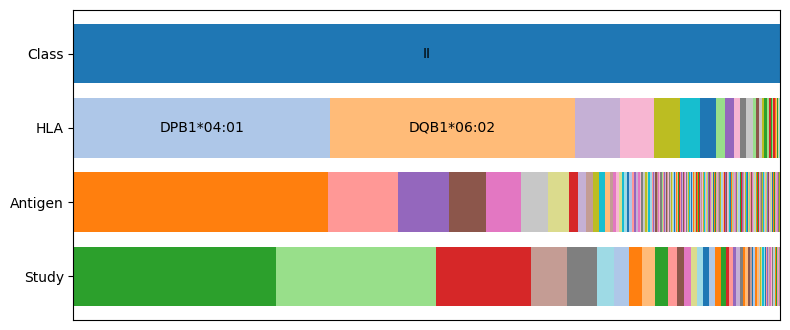

In [45]:
mhc_class = iedb_II.select("mhc_class").to_series().to_list()
hla_allele = iedb_II.select(pl.col("mhc_2_name").str.slice(0, 10)).to_series().to_list()
antigen = iedb_II.select(pl.concat_str(["mhc_2_name", "peptide"])).to_series().to_list()
study = iedb_II.select("references").to_series().to_list()

plot_stacked_category_proportions(
    ["Class", "HLA", "Antigen", "Study"],
    [mhc_class, hla_allele, antigen, study],
    annotate=[True, True, False, False],
)

(<Figure size 800x340 with 1 Axes>, <Axes: >)

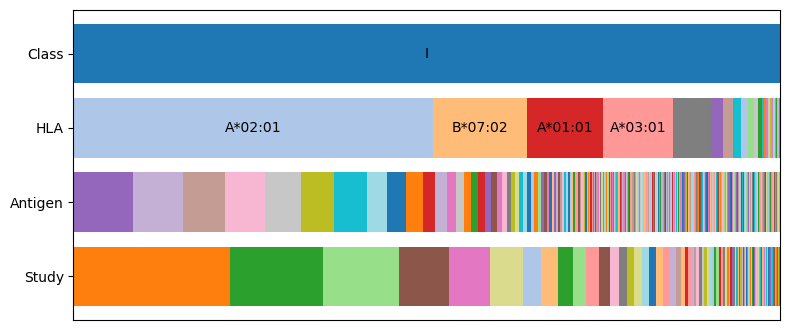

In [46]:
mhc_class = iedb_I.select("mhc_class").to_series().to_list()
hla_allele = iedb_I.select(pl.col("mhc_1_name")).to_series().to_list()
antigen = iedb_I.select(pl.concat_str(["mhc_1_name", "peptide"])).to_series().to_list()
study = iedb_I.select("references").to_series().to_list()

plot_stacked_category_proportions(
    ["Class", "HLA", "Antigen", "Study"], [mhc_class, hla_allele, antigen, study], annotate=[True, True, False, False],
)